In [1]:
# 📊 Évaluation des modèles — Étape 7

import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.ensemble import StackingRegressor

# 🔹 Chargement des données
X_train = pd.read_csv("../Data/X_train_encoded.csv")
y_train_log = pd.read_csv("../Data/y_train_log.csv").squeeze()

selected_features = [
    'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars',
    '1stFlrSF', 'BsmtFinSF1', 'YearBuilt', 'YearRemodAdd', 'GarageArea',
    'TotRmsAbvGrd', 'Fireplaces', 'MasVnrArea', 'LotArea', '2ndFlrSF',
    'FullBath', 'OpenPorchSF', 'HalfBath', 'WoodDeckSF', 'KitchenAbvGr',
    'GarageYrBlt', 'BsmtUnfSF', 'BedroomAbvGr', 'ScreenPorch', 'LotFrontage',
    'MoSold', 'GarageFinish_Unf', 'KitchenQual_TA',
    'Neighborhood_NridgHt', 'BsmtQual_TA'
]

X_train_sel = X_train[selected_features]

# 🔹 Meilleurs modèles (déjà optimisés avec Optuna)
ridge_best = Ridge(alpha=15.47)
lasso_best = Lasso(alpha=0.000106, max_iter=5000)
xgb_best = XGBRegressor(
    n_estimators=659,
    max_depth=5,
    learning_rate=0.0101,
    subsample=0.518,
    colsample_bytree=0.817,
    random_state=42,
    verbosity=0
)

# 🔹 Évaluation individuelle des modèles
for name, model in {
    "Ridge": ridge_best,
    "Lasso": lasso_best,
    "XGBoost": xgb_best
}.items():
    scores = cross_val_score(model, X_train_sel, y_train_log, cv=5, scoring="neg_root_mean_squared_error")
    print(f"✅ {name} RMSE moyen : {-scores.mean():.4f}")

# 🔹 Évaluation du Stacking
stacked_model = StackingRegressor(
    estimators=[
        ('ridge', ridge_best),
        ('lasso', lasso_best),
        ('xgb', xgb_best)
    ],
    final_estimator=Ridge(alpha=1.0),
    passthrough=False,
    cv=5,
    n_jobs=-1
)

scores = cross_val_score(stacked_model, X_train_sel, y_train_log, cv=5, scoring="neg_root_mean_squared_error")
print(f"🔄 Stacking RMSE moyen : {-scores.mean():.4f}")


✅ Ridge RMSE moyen : 0.1625
✅ Lasso RMSE moyen : 0.1627
✅ XGBoost RMSE moyen : 0.1383
🔄 Stacking RMSE moyen : 0.1405


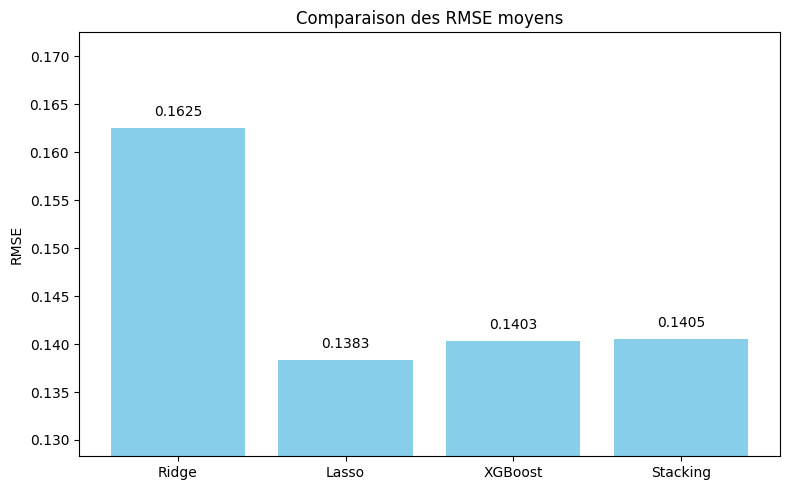

In [2]:
import matplotlib.pyplot as plt

# 🔹 Comparaison visuelle des scores
model_names = ['Ridge', 'Lasso', 'XGBoost', 'Stacking']
rmse_scores = [0.1625, 0.1383, 0.1403, 0.1405]  # Ou utilise directement tes variables si tu les as stockées

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, rmse_scores, color='skyblue')
plt.title('Comparaison des RMSE moyens')
plt.ylabel('RMSE')
plt.ylim(min(rmse_scores) - 0.01, max(rmse_scores) + 0.01)

# Ajout des valeurs sur les barres
for bar, score in zip(bars, rmse_scores):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.001, f'{score:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()
